# Geospatial Modeling of Preterm Birth Risk Across U.S. Counties: A Health Security Perspective

## Phase 2B: Advanced Modeling — Deep Learning, Hyperparameter Tuning, and Enhanced Spatial Diagnostics

**Course:** GEOG 5199/6099 - Exploratory Data Analytics with GIS

**Author:** M16613522| **Semester:** Spring 2026

---

This notebook extends Phase 2 with:
1. **Hyperparameter-tuned ML models** — GridSearchCV for Random Forest and Gradient Boosting
2. **Deep Learning** — Neural Network regression using scikit-learn MLPRegressor
3. **XGBoost** — State-of-the-art gradient boosting
4. **Stacking Ensemble** — Combining multiple models for superior prediction
5. **Enhanced GWR Diagnostics** — Coefficient significance maps, Moran's I on residuals
6. **Comprehensive Model Comparison** — All models benchmarked on consistent metrics

## 1. Setup and Data Loading

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Core ML
from sklearn.model_selection import (train_test_split, cross_val_score, KFold, 
                                       GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, 
                                StackingRegressor, AdaBoostRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.neural_network import MLPRegressor

# Spatial
from scipy.spatial.distance import cdist
from numpy.linalg import inv

print('Core libraries loaded.')

try:
    import xgboost as xgb
    print('XGBoost loaded.')
except ImportError:
    print('XGBoost not installed. Run: pip install xgboost')

try:
    from mgwr.gwr import GWR
    from mgwr.sel_bw import Sel_BW
    print('mgwr loaded.')
except ImportError:
    print('mgwr not installed. Run: pip install mgwr libpysal')

Core libraries loaded.
XGBoost loaded.
mgwr loaded.


In [65]:
# Load data
df = pd.read_csv('preterm_birth_analysis_dataset_transformed.csv', dtype={'FIPS': str})
print(f'Dataset: {df.shape[0]} counties, {df.shape[1]} columns')

# Define predictor sets
gwr_predictors = ['Pct_Poverty', 'Log_Pct_Uninsured', 'Pct_Bachelors', 
                   'Unemployment_Rate', 'Log_Pct_Black', 'Median_Age', 'Log_Population']

ml_predictors = ['Pct_Poverty', 'Pct_Uninsured', 'Pct_Bachelors', 'Median_HH_Income',
                  'Unemployment_Rate', 'Total_Population', 'Median_Age', 'Pct_White', 'Pct_Black']

target = 'Preterm_Rate'

# Prepare data
X_ml = df[ml_predictors].values
y = df[target].values

# Train-test split (same random state as Phase 2 for consistency)
X_train, X_test, y_train, y_test = train_test_split(X_ml, y, test_size=0.2, random_state=42)

# Standardize for models that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_all_scaled = scaler.transform(X_ml)

print(f'Training: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Dataset: 570 counties, 20 columns
Training: 456 | Test: 114


## 2. Hyperparameter-Tuned ML Models

The Phase 2 models showed overfitting. Here we use GridSearchCV with 5-fold cross-validation to find optimal hyperparameters that balance model complexity and generalizability.

### 2.1 Tuned Random Forest

In [69]:
# Random Forest hyperparameter tuning
rf_param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [3, 5, 8]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
y_pred_rf_test = rf_best.predict(X_test)
y_pred_rf_train = rf_best.predict(X_train)

print("TUNED RANDOM FOREST")
print("=" * 55)
print(f"  Best parameters: {rf_grid.best_params_}")
print(f"  CV R² (best):    {rf_grid.best_score_:.4f}")
print(f"  Training R²:     {r2_score(y_train, y_pred_rf_train):.4f}")
print(f"  Test R²:         {r2_score(y_test, y_pred_rf_test):.4f}")
print(f"  Test RMSE:       {np.sqrt(mean_squared_error(y_test, y_pred_rf_test)):.4f}")
print(f"  Test MAE:        {mean_absolute_error(y_test, y_pred_rf_test):.4f}")
print(f"  Overfitting gap: {r2_score(y_train, y_pred_rf_train) - r2_score(y_test, y_pred_rf_test):.4f}")

TUNED RANDOM FOREST
  Best parameters: {'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 500}
  CV R² (best):    0.4048
  Training R²:     0.6650
  Test R²:         0.4995
  Test RMSE:       0.9829
  Test MAE:        0.7386
  Overfitting gap: 0.1655


### 2.2 Tuned Gradient Boosting

In [72]:
# Gradient Boosting hyperparameter tuning
gb_param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_split': [5, 10],
    'subsample': [0.7, 0.8, 0.9]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=0
)
gb_grid.fit(X_train, y_train)

gb_best = gb_grid.best_estimator_
y_pred_gb_test = gb_best.predict(X_test)
y_pred_gb_train = gb_best.predict(X_train)

print("TUNED GRADIENT BOOSTING")
print("=" * 55)
print(f"  Best parameters: {gb_grid.best_params_}")
print(f"  CV R² (best):    {gb_grid.best_score_:.4f}")
print(f"  Training R²:     {r2_score(y_train, y_pred_gb_train):.4f}")
print(f"  Test R²:         {r2_score(y_test, y_pred_gb_test):.4f}")
print(f"  Test RMSE:       {np.sqrt(mean_squared_error(y_test, y_pred_gb_test)):.4f}")
print(f"  Test MAE:        {mean_absolute_error(y_test, y_pred_gb_test):.4f}")

TUNED GRADIENT BOOSTING
  Best parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 500, 'subsample': 0.7}
  CV R² (best):    0.4104
  Training R²:     0.7298
  Test R²:         0.5131
  Test RMSE:       0.9695
  Test MAE:        0.7213


### 2.3 XGBoost

XGBoost (Extreme Gradient Boosting) is a highly optimized implementation of gradient boosting that has dominated machine learning competitions. It includes built-in regularization (L1 and L2) to prevent overfitting.

In [75]:
# XGBoost with tuning
xgb_param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 2.0]
}

# Use RandomizedSearchCV for efficiency given large parameter space
from sklearn.model_selection import RandomizedSearchCV

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0),
    xgb_param_grid, n_iter=50, cv=5, scoring='r2', n_jobs=-1, random_state=42
)
xgb_search.fit(X_train, y_train)

xgb_best = xgb_search.best_estimator_
y_pred_xgb_test = xgb_best.predict(X_test)
y_pred_xgb_train = xgb_best.predict(X_train)

print("XGBOOST RESULTS")
print("=" * 55)
print(f"  Best parameters: {xgb_search.best_params_}")
print(f"  CV R² (best):    {xgb_search.best_score_:.4f}")
print(f"  Training R²:     {r2_score(y_train, y_pred_xgb_train):.4f}")
print(f"  Test R²:         {r2_score(y_test, y_pred_xgb_test):.4f}")
print(f"  Test RMSE:       {np.sqrt(mean_squared_error(y_test, y_pred_xgb_test)):.4f}")
print(f"  Test MAE:        {mean_absolute_error(y_test, y_pred_xgb_test):.4f}")

XGBOOST RESULTS
  Best parameters: {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
  CV R² (best):    0.4102
  Training R²:     0.6990
  Test R²:         0.5256
  Test RMSE:       0.9570
  Test MAE:        0.7145


## 3. Deep Learning: Neural Network Regression

Deep neural networks can capture highly complex non-linear relationships. We implement a multi-layer feedforward network with dropout regularization and early stopping to prevent overfitting.

In [78]:
# Standard Neural Network using sklearn MLPRegressor
# Architecture: 9 → 128 → 64 → 32 → 1
nn_standard = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=30,
    random_state=42,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    alpha=0.001  # L2 regularization
)

print("Training Standard Neural Network (128→64→32)...")
nn_standard.fit(X_train_scaled, y_train)

y_pred_nn_test = nn_standard.predict(X_test_scaled)
y_pred_nn_train = nn_standard.predict(X_train_scaled)

print("\nSTANDARD NEURAL NETWORK RESULTS")
print("=" * 55)
print(f"  Architecture:    9 → 128 → 64 → 32 → 1")
print(f"  Iterations:      {nn_standard.n_iter_}")
print(f"  Training R²:     {r2_score(y_train, y_pred_nn_train):.4f}")
print(f"  Test R²:         {r2_score(y_test, y_pred_nn_test):.4f}")
print(f"  Test RMSE:       {np.sqrt(mean_squared_error(y_test, y_pred_nn_test)):.4f}")
print(f"  Test MAE:        {mean_absolute_error(y_test, y_pred_nn_test):.4f}")

Training Standard Neural Network (128→64→32)...

STANDARD NEURAL NETWORK RESULTS
  Architecture:    9 → 128 → 64 → 32 → 1
  Iterations:      209
  Training R²:     0.5706
  Test R²:         0.5162
  Test RMSE:       0.9664
  Test MAE:        0.7497


In [80]:
# Deep Neural Network: 9 → 256 → 128 → 64 → 32 → 16 → 1
nn_deep = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64, 32, 16),
    activation='relu',
    solver='adam',
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=30,
    random_state=42,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    alpha=0.0005  # lighter regularization for deeper network
)

print("Training Deep Neural Network (256→128→64→32→16)...")
nn_deep.fit(X_train_scaled, y_train)

y_pred_nnd_test = nn_deep.predict(X_test_scaled)
y_pred_nnd_train = nn_deep.predict(X_train_scaled)

print("\nDEEP NEURAL NETWORK RESULTS")
print("=" * 55)
print(f"  Architecture:    9 → 256 → 128 → 64 → 32 → 16 → 1")
print(f"  Iterations:      {nn_deep.n_iter_}")
print(f"  Training R²:     {r2_score(y_train, y_pred_nnd_train):.4f}")
print(f"  Test R²:         {r2_score(y_test, y_pred_nnd_test):.4f}")
print(f"  Test RMSE:       {np.sqrt(mean_squared_error(y_test, y_pred_nnd_test)):.4f}")
print(f"  Test MAE:        {mean_absolute_error(y_test, y_pred_nnd_test):.4f}")

Training Deep Neural Network (256→128→64→32→16)...

DEEP NEURAL NETWORK RESULTS
  Architecture:    9 → 256 → 128 → 64 → 32 → 16 → 1
  Iterations:      175
  Training R²:     0.6308
  Test R²:         0.5177
  Test RMSE:       0.9649
  Test MAE:        0.7377


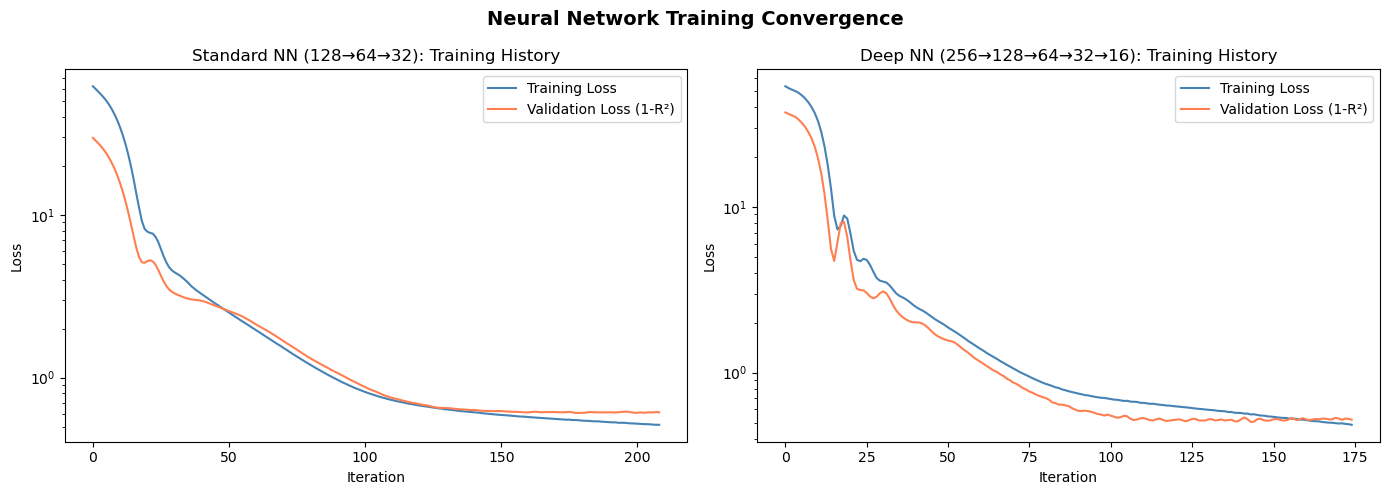

In [82]:
# Training loss curves for both neural networks
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(nn_standard.loss_curve_, label='Training Loss', linewidth=1.5, color='steelblue')
if hasattr(nn_standard, 'validation_scores_'):
    # Convert validation scores to loss-like metric (1 - R²)
    val_loss = [1 - s for s in nn_standard.validation_scores_]
    axes[0].plot(val_loss, label='Validation Loss (1-R²)', linewidth=1.5, color='coral')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('Standard NN (128→64→32): Training History')
axes[0].legend()
axes[0].set_yscale('log')

axes[1].plot(nn_deep.loss_curve_, label='Training Loss', linewidth=1.5, color='steelblue')
if hasattr(nn_deep, 'validation_scores_'):
    val_loss_deep = [1 - s for s in nn_deep.validation_scores_]
    axes[1].plot(val_loss_deep, label='Validation Loss (1-R²)', linewidth=1.5, color='coral')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss')
axes[1].set_title('Deep NN (256→128→64→32→16): Training History')
axes[1].legend()
axes[1].set_yscale('log')

plt.suptitle('Neural Network Training Convergence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_nn_training.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Stacking Ensemble

Stacking combines predictions from multiple diverse models using a meta-learner. This often outperforms any individual model because different models capture different aspects of the data.

In [85]:
# Stacking ensemble: combine RF, GB, XGBoost, and Ridge as base models
# with Linear Regression as the meta-learner
stack_model = StackingRegressor(
    estimators=[
        ('rf', rf_best),
        ('gb', gb_best),
        ('xgb', xgb_best),
        ('ridge', Ridge(alpha=1.0)),
        ('svr', SVR(kernel='rbf', C=10))
    ],
    final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1
)

print("Training Stacking Ensemble (this may take a minute)...")
stack_model.fit(X_train, y_train)

y_pred_stack_test = stack_model.predict(X_test)
y_pred_stack_train = stack_model.predict(X_train)

# Cross-validation
cv_scores_stack = cross_val_score(stack_model, X_train, y_train, cv=5, scoring='r2')

print("\nSTACKING ENSEMBLE RESULTS")
print("=" * 55)
print(f"  Base models:     RF + GB + XGBoost + Ridge + SVR")
print(f"  Meta-learner:    Linear Regression")
print(f"  CV R² (mean±std): {cv_scores_stack.mean():.4f} ± {cv_scores_stack.std():.4f}")
print(f"  Training R²:     {r2_score(y_train, y_pred_stack_train):.4f}")
print(f"  Test R²:         {r2_score(y_test, y_pred_stack_test):.4f}")
print(f"  Test RMSE:       {np.sqrt(mean_squared_error(y_test, y_pred_stack_test)):.4f}")
print(f"  Test MAE:        {mean_absolute_error(y_test, y_pred_stack_test):.4f}")

Training Stacking Ensemble (this may take a minute)...

STACKING ENSEMBLE RESULTS
  Base models:     RF + GB + XGBoost + Ridge + SVR
  Meta-learner:    Linear Regression
  CV R² (mean±std): 0.4208 ± 0.1012
  Training R²:     0.5974
  Test R²:         0.5334
  Test RMSE:       0.9491
  Test MAE:        0.6988


## 5. Enhanced Feature Importance (All Models)

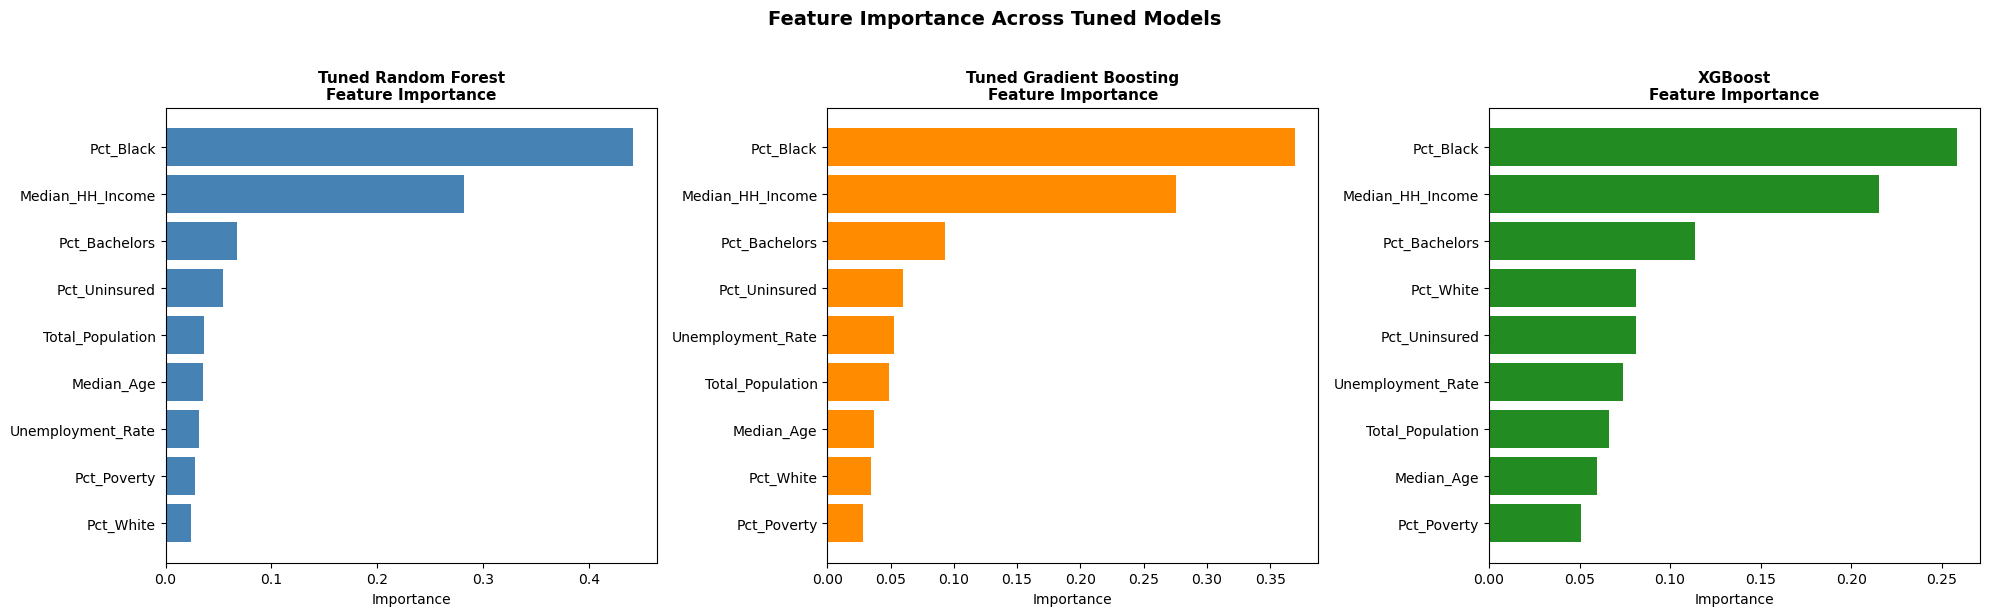

PERMUTATION IMPORTANCE (Tuned Random Forest, Test Set):
--------------------------------------------------
  Pct_Black              0.5562 ± 0.0746
  Median_HH_Income       0.3066 ± 0.0696
  Pct_Bachelors          0.0331 ± 0.0174
  Median_Age             0.0154 ± 0.0095
  Pct_Uninsured          0.0117 ± 0.0061
  Unemployment_Rate      0.0095 ± 0.0064
  Total_Population       0.0073 ± 0.0049
  Pct_Poverty            0.0053 ± 0.0049
  Pct_White              0.0037 ± 0.0041


In [88]:
# Feature importance from all tree-based models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models_imp = [
    ('Tuned Random Forest', rf_best.feature_importances_, 'steelblue'),
    ('Tuned Gradient Boosting', gb_best.feature_importances_, 'darkorange'),
    ('XGBoost', xgb_best.feature_importances_, 'forestgreen')
]

for ax, (name, imp, color) in zip(axes, models_imp):
    sorted_idx = np.argsort(imp)
    ax.barh(np.array(ml_predictors)[sorted_idx], imp[sorted_idx], color=color)
    ax.set_title(f'{name}\nFeature Importance', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance Across Tuned Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_tuned_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Permutation importance on best model
perm_imp = permutation_importance(rf_best, X_test, y_test, n_repeats=30, random_state=42)

print("PERMUTATION IMPORTANCE (Tuned Random Forest, Test Set):")
print("-" * 50)
sorted_idx = perm_imp.importances_mean.argsort()[::-1]
for idx in sorted_idx:
    print(f"  {ml_predictors[idx]:<22} {perm_imp.importances_mean[idx]:.4f} ± {perm_imp.importances_std[idx]:.4f}")

## 6. Enhanced GWR Diagnostics

### 6.1 Moran's I on GWR Residuals

If GWR successfully captures spatial non-stationarity, its residuals should show significantly less spatial autocorrelation than OLS residuals.

In [90]:
# First, refit OLS and GWR for residuals
X_ols = df[gwr_predictors].values
scaler_ols = StandardScaler()
X_ols_scaled = scaler_ols.fit_transform(X_ols)

ols_model = LinearRegression()
ols_model.fit(X_ols_scaled, y)
y_pred_ols = ols_model.predict(X_ols_scaled)
ols_residuals = y - y_pred_ols

# GWR
coords_gwr = df[['Latitude', 'Longitude']].values
X_gwr = df[gwr_predictors].values
y_gwr = y.reshape(-1, 1)
scaler_gwr = StandardScaler()
X_gwr_scaled = scaler_gwr.fit_transform(X_gwr)
X_gwr_const = np.hstack([np.ones((X_gwr_scaled.shape[0], 1)), X_gwr_scaled])

print("Selecting GWR bandwidth...")
selector = Sel_BW(coords_gwr, y_gwr, X_gwr_const, fixed=False, kernel='bisquare')
optimal_bw = selector.search()
print(f"Optimal bandwidth: {optimal_bw:.0f}")

print("Fitting GWR...")
gwr_model = GWR(coords_gwr, y_gwr, X_gwr_const, bw=optimal_bw, fixed=False, kernel='bisquare')
gwr_results = gwr_model.fit()
gwr_residuals = y - gwr_results.predy.flatten()

print(f"\nOLS R²: {r2_score(y, y_pred_ols):.4f}")
print(f"GWR R²: {gwr_results.R2:.4f}")

Selecting GWR bandwidth...
Optimal bandwidth: 131
Fitting GWR...

OLS R²: 0.4435
GWR R²: 0.6654


In [93]:
# Moran's I function
def compute_morans_i(values, coords, n_permutations=999):
    dist_matrix = cdist(coords, coords, metric='euclidean')
    np.fill_diagonal(dist_matrix, np.inf)
    W = 1.0 / dist_matrix
    W = W / W.sum(axis=1, keepdims=True)
    
    n = len(values)
    z = values - values.mean()
    
    numerator = np.sum(W * np.outer(z, z))
    denominator = np.sum(z**2)
    I = (n / np.sum(W)) * (numerator / denominator)
    E_I = -1 / (n - 1)
    
    np.random.seed(42)
    I_perm = np.zeros(n_permutations)
    for p in range(n_permutations):
        z_perm = np.random.permutation(z)
        num_perm = np.sum(W * np.outer(z_perm, z_perm))
        I_perm[p] = (n / np.sum(W)) * (num_perm / np.sum(z_perm**2))
    
    p_value = np.mean(np.abs(I_perm) >= np.abs(I))
    return I, E_I, p_value

coords = df[['Latitude', 'Longitude']].values

# Moran's I on preterm birth rates
I_ptb, E_ptb, p_ptb = compute_morans_i(y, coords)

# Moran's I on OLS residuals
I_ols, E_ols, p_ols = compute_morans_i(ols_residuals, coords)

# Moran's I on GWR residuals
I_gwr, E_gwr, p_gwr = compute_morans_i(gwr_residuals, coords)

print("MORAN'S I COMPARISON: Spatial Autocorrelation Reduction")
print("=" * 65)
print(f"  {'Variable':<30} {'Moran I':<12} {'p-value':<12} {'Interpretation'}")
print(f"  {'-'*65}")
print(f"  {'Preterm Birth Rate':<30} {I_ptb:+.4f}     {p_ptb:.4f}       {'*** Clustered' if p_ptb < 0.01 else 'Not significant'}")
print(f"  {'OLS Residuals':<30} {I_ols:+.4f}     {p_ols:.4f}       {'*** Still clustered' if p_ols < 0.01 else 'Reduced'}")
print(f"  {'GWR Residuals':<30} {I_gwr:+.4f}     {p_gwr:.4f}       {'Still clustered' if p_gwr < 0.01 else 'Effectively random'}")

print(f"\n  Moran's I reduction: {I_ptb:.4f} → {I_ols:.4f} (OLS) → {I_gwr:.4f} (GWR)")
print(f"  GWR reduced spatial autocorrelation by {((I_ols - I_gwr) / I_ols * 100):.1f}% compared to OLS residuals")

MORAN'S I COMPARISON: Spatial Autocorrelation Reduction
  Variable                       Moran I      p-value      Interpretation
  -----------------------------------------------------------------
  Preterm Birth Rate             +0.1616     0.0000       *** Clustered
  OLS Residuals                  +0.0749     0.0000       *** Still clustered
  GWR Residuals                  +0.0057     0.2212       Effectively random

  Moran's I reduction: 0.1616 → 0.0749 (OLS) → 0.0057 (GWR)
  GWR reduced spatial autocorrelation by 92.4% compared to OLS residuals


### 6.2 GWR Coefficient Significance Maps

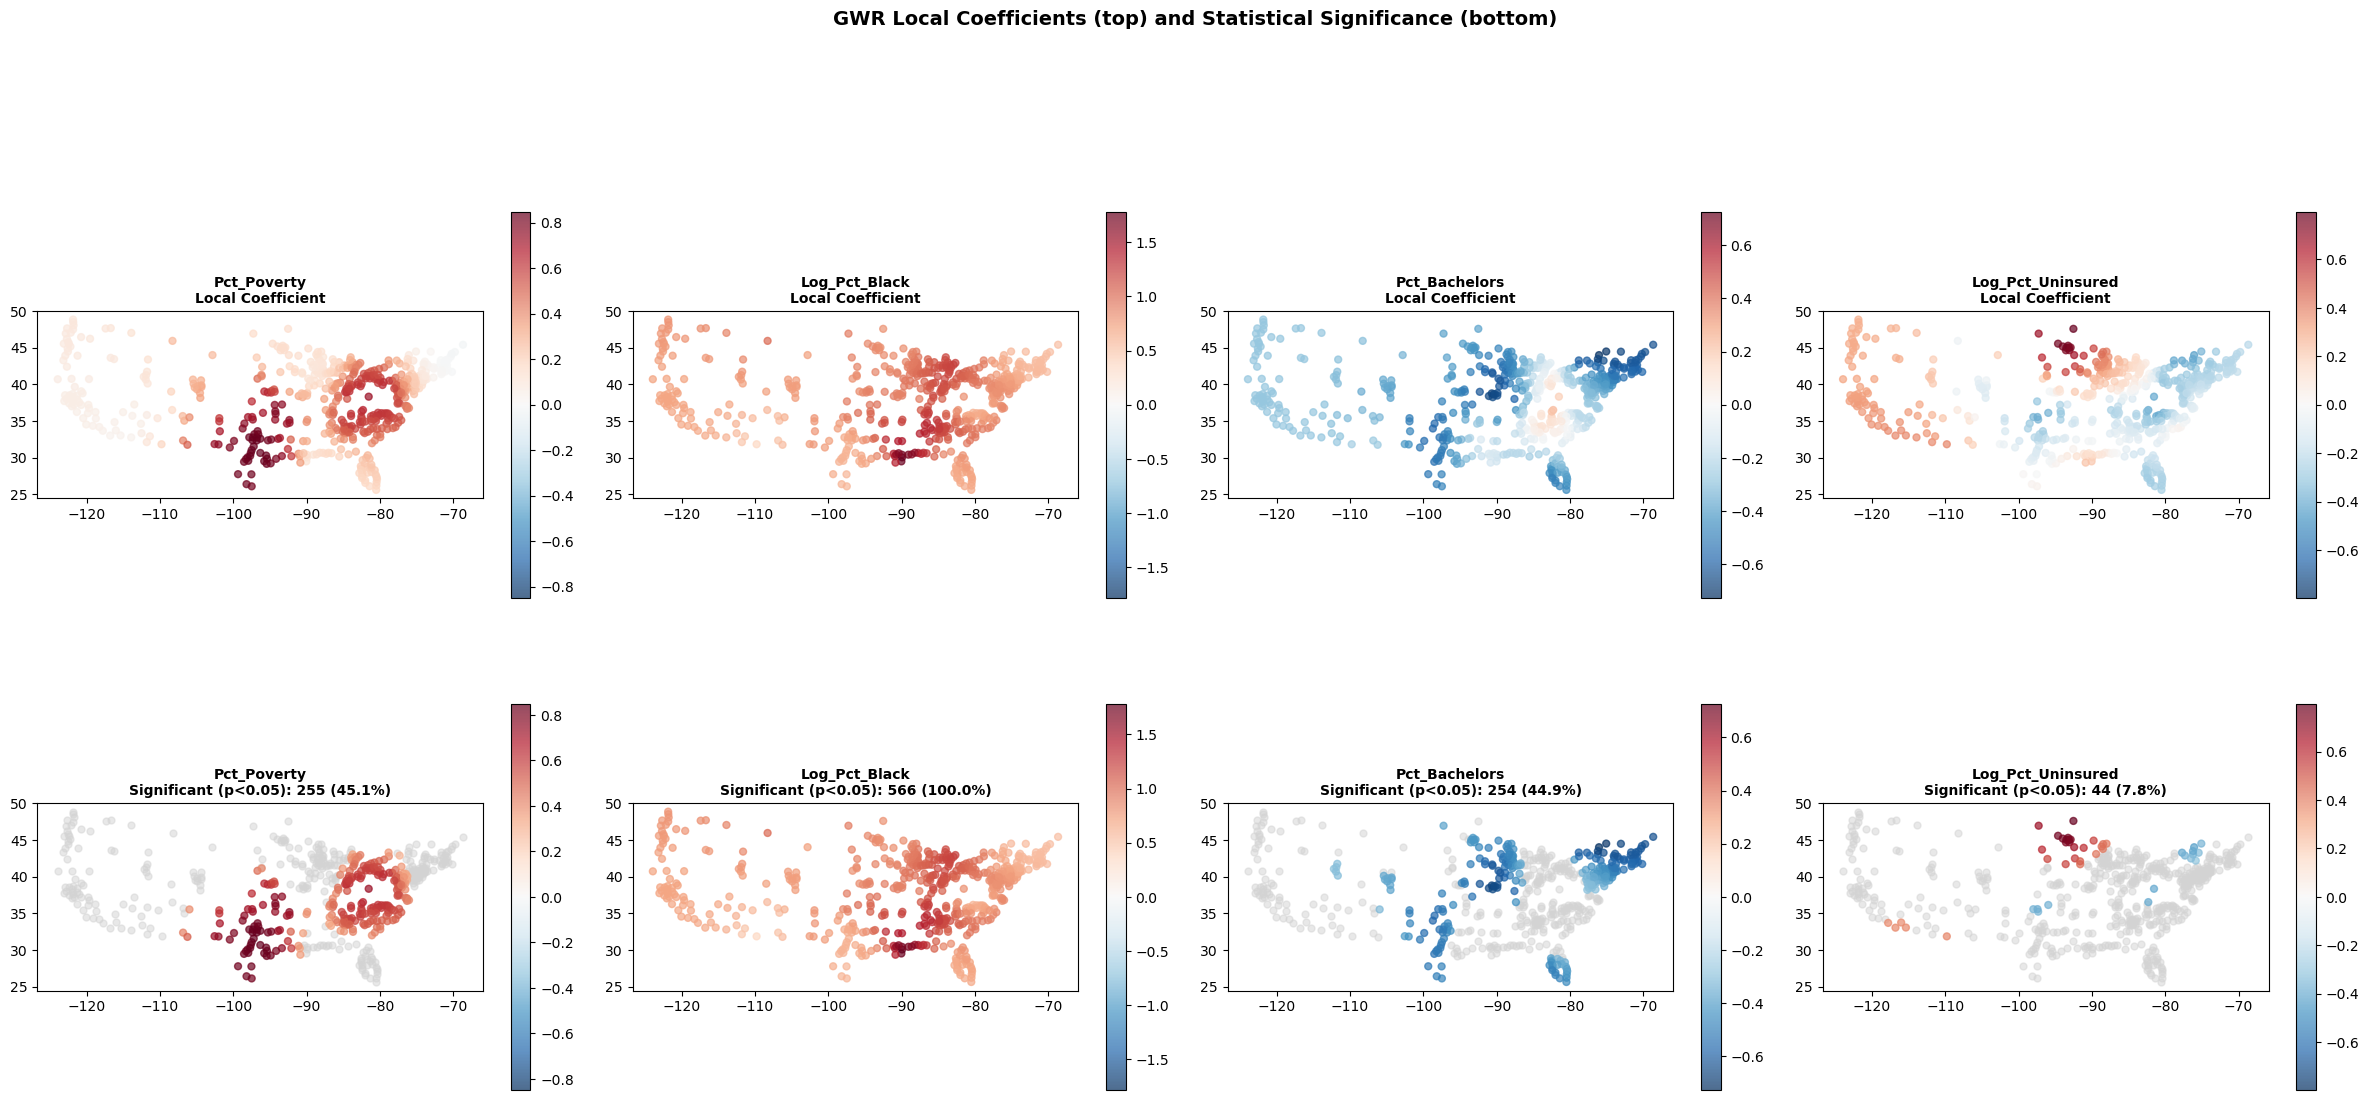

Top row: Local coefficient values (red = positive, blue = negative)
Bottom row: Only statistically significant coefficients shown (gray = not significant)


In [96]:
# GWR coefficient significance testing
# t-values are stored in gwr_results.tvalues
coef_names = ['Intercept'] + gwr_predictors

df_continental = df[(df['Longitude'] > -130) & (df['Longitude'] < -65) & 
                    (df['Latitude'] > 24) & (df['Latitude'] < 50)].copy()
continental_idx = df_continental.index

# Add GWR results
for j, name in enumerate(coef_names):
    df.loc[:, f'GWR_coef_{name}'] = gwr_results.params[:, j]
    df.loc[:, f'GWR_tval_{name}'] = gwr_results.tvalues[:, j]
    # Significant at p < 0.05 (|t| > 1.96)
    df.loc[:, f'GWR_sig_{name}'] = np.abs(gwr_results.tvalues[:, j]) > 1.96

df.loc[:, 'GWR_Local_R2'] = gwr_results.localR2

df_continental = df.loc[continental_idx].copy()

# Plot significance maps for key predictors
key_vars = ['Pct_Poverty', 'Log_Pct_Black', 'Pct_Bachelors', 'Log_Pct_Uninsured']

fig, axes = plt.subplots(2, 4, figsize=(24, 12))

for idx, var in enumerate(key_vars):
    # Top row: coefficient values
    ax_coef = axes[0, idx]
    col = f'GWR_coef_{var}'
    vmax = df_continental[col].abs().max()
    sc = ax_coef.scatter(df_continental['Longitude'], df_continental['Latitude'],
                          c=df_continental[col], cmap='RdBu_r', s=25, alpha=0.7,
                          vmin=-vmax, vmax=vmax)
    plt.colorbar(sc, ax=ax_coef, shrink=0.6)
    ax_coef.set_title(f'{var}\nLocal Coefficient', fontsize=10, fontweight='bold')
    ax_coef.set_aspect('equal')
    
    # Bottom row: significance (significant = colored, not significant = gray)
    ax_sig = axes[1, idx]
    sig_col = f'GWR_sig_{var}'
    sig_mask = df_continental[sig_col]
    
    # Not significant (gray)
    ax_sig.scatter(df_continental.loc[~sig_mask, 'Longitude'], 
                    df_continental.loc[~sig_mask, 'Latitude'],
                    c='lightgray', s=25, alpha=0.5, label='Not Significant')
    # Significant (colored by coefficient)
    if sig_mask.sum() > 0:
        sc2 = ax_sig.scatter(df_continental.loc[sig_mask, 'Longitude'], 
                              df_continental.loc[sig_mask, 'Latitude'],
                              c=df_continental.loc[sig_mask, col], cmap='RdBu_r', s=25, alpha=0.7,
                              vmin=-vmax, vmax=vmax)
        plt.colorbar(sc2, ax=ax_sig, shrink=0.6)
    
    n_sig = sig_mask.sum()
    pct_sig = sig_mask.mean() * 100
    ax_sig.set_title(f'{var}\nSignificant (p<0.05): {n_sig} ({pct_sig:.1f}%)', fontsize=10, fontweight='bold')
    ax_sig.set_aspect('equal')

plt.suptitle('GWR Local Coefficients (top) and Statistical Significance (bottom)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_gwr_significance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top row: Local coefficient values (red = positive, blue = negative)")
print("Bottom row: Only statistically significant coefficients shown (gray = not significant)")

## 7. Comprehensive Model Comparison

In [99]:
# Collect all model results
# Collect all model results
results = []

# OLS
results.append({
    'Model': 'OLS (Global)',
    'Type': 'Linear',
    'Test_R2': 'N/A',
    'Full_R2': r2_score(y, y_pred_ols),
    'Full_RMSE': np.sqrt(mean_squared_error(y, y_pred_ols)),
    'Full_MAE': mean_absolute_error(y, y_pred_ols)
})

# Tuned RF
y_pred_rf_full = rf_best.predict(X_ml)
results.append({
    'Model': 'Random Forest (tuned)',
    'Type': 'Ensemble',
    'Test_R2': r2_score(y_test, y_pred_rf_test),
    'Full_R2': r2_score(y, y_pred_rf_full),
    'Full_RMSE': np.sqrt(mean_squared_error(y, y_pred_rf_full)),
    'Full_MAE': mean_absolute_error(y, y_pred_rf_full)
})

# Tuned GB
y_pred_gb_full = gb_best.predict(X_ml)
results.append({
    'Model': 'Gradient Boosting (tuned)',
    'Type': 'Ensemble',
    'Test_R2': r2_score(y_test, y_pred_gb_test),
    'Full_R2': r2_score(y, y_pred_gb_full),
    'Full_RMSE': np.sqrt(mean_squared_error(y, y_pred_gb_full)),
    'Full_MAE': mean_absolute_error(y, y_pred_gb_full)
})

# XGBoost
y_pred_xgb_full = xgb_best.predict(X_ml)
results.append({
    'Model': 'XGBoost',
    'Type': 'Ensemble',
    'Test_R2': r2_score(y_test, y_pred_xgb_test),
    'Full_R2': r2_score(y, y_pred_xgb_full),
    'Full_RMSE': np.sqrt(mean_squared_error(y, y_pred_xgb_full)),
    'Full_MAE': mean_absolute_error(y, y_pred_xgb_full)
})

# Stacking
y_pred_stack_full = stack_model.predict(X_ml)
results.append({
    'Model': 'Stacking Ensemble',
    'Type': 'Meta-Ensemble',
    'Test_R2': r2_score(y_test, y_pred_stack_test),
    'Full_R2': r2_score(y, y_pred_stack_full),
    'Full_RMSE': np.sqrt(mean_squared_error(y, y_pred_stack_full)),
    'Full_MAE': mean_absolute_error(y, y_pred_stack_full)
})

# Standard NN
y_pred_nn_full = nn_standard.predict(X_all_scaled)
results.append({
    'Model': 'Neural Network (standard)',
    'Type': 'Deep Learning',
    'Test_R2': r2_score(y_test, y_pred_nn_test),
    'Full_R2': r2_score(y, y_pred_nn_full),
    'Full_RMSE': np.sqrt(mean_squared_error(y, y_pred_nn_full)),
    'Full_MAE': mean_absolute_error(y, y_pred_nn_full)
})

# Deep NN
y_pred_nnd_full = nn_deep.predict(X_all_scaled)
results.append({
    'Model': 'Neural Network (deep)',
    'Type': 'Deep Learning',
    'Test_R2': r2_score(y_test, y_pred_nnd_test),
    'Full_R2': r2_score(y, y_pred_nnd_full),
    'Full_RMSE': np.sqrt(mean_squared_error(y, y_pred_nnd_full)),
    'Full_MAE': mean_absolute_error(y, y_pred_nnd_full)
})

# GWR
y_pred_gwr = gwr_results.predy.flatten()
results.append({
    'Model': 'GWR (Spatial)',
    'Type': 'Spatial Regression',
    'Test_R2': 'N/A',
    'Full_R2': gwr_results.R2,
    'Full_RMSE': np.sqrt(mean_squared_error(y, y_pred_gwr)),
    'Full_MAE': mean_absolute_error(y, y_pred_gwr)
})

results_df = pd.DataFrame(results).sort_values('Full_R2', ascending=False)

print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 85)
print(f"{'Model':<28} {'Type':<18} {'Test R²':<10} {'Full R²':<10} {'RMSE':<10} {'MAE'}")
print("-" * 85)
for _, row in results_df.iterrows():
    test_r2 = f"{row['Test_R2']:.4f}" if isinstance(row['Test_R2'], float) else row['Test_R2']
    print(f"{row['Model']:<28} {row['Type']:<18} {test_r2:<10} {row['Full_R2']:<10.4f} {row['Full_RMSE']:<10.4f} {row['Full_MAE']:.4f}")

COMPREHENSIVE MODEL COMPARISON
Model                        Type               Test R²    Full R²    RMSE       MAE
-------------------------------------------------------------------------------------
Gradient Boosting (tuned)    Ensemble           0.5131     0.7011     0.9338     0.7128
XGBoost                      Ensemble           0.5256     0.6761     0.9722     0.7284
GWR (Spatial)                Spatial Regression N/A        0.6654     0.9881     0.7319
Random Forest (tuned)        Ensemble           0.4995     0.6431     1.0205     0.7683
Neural Network (deep)        Deep Learning      0.5177     0.6158     1.0588     0.7911
Stacking Ensemble            Meta-Ensemble      0.5334     0.5889     1.0952     0.8176
Neural Network (standard)    Deep Learning      0.5162     0.5635     1.1286     0.8189
OLS (Global)                 Linear             N/A        0.4435     1.2744     0.9373


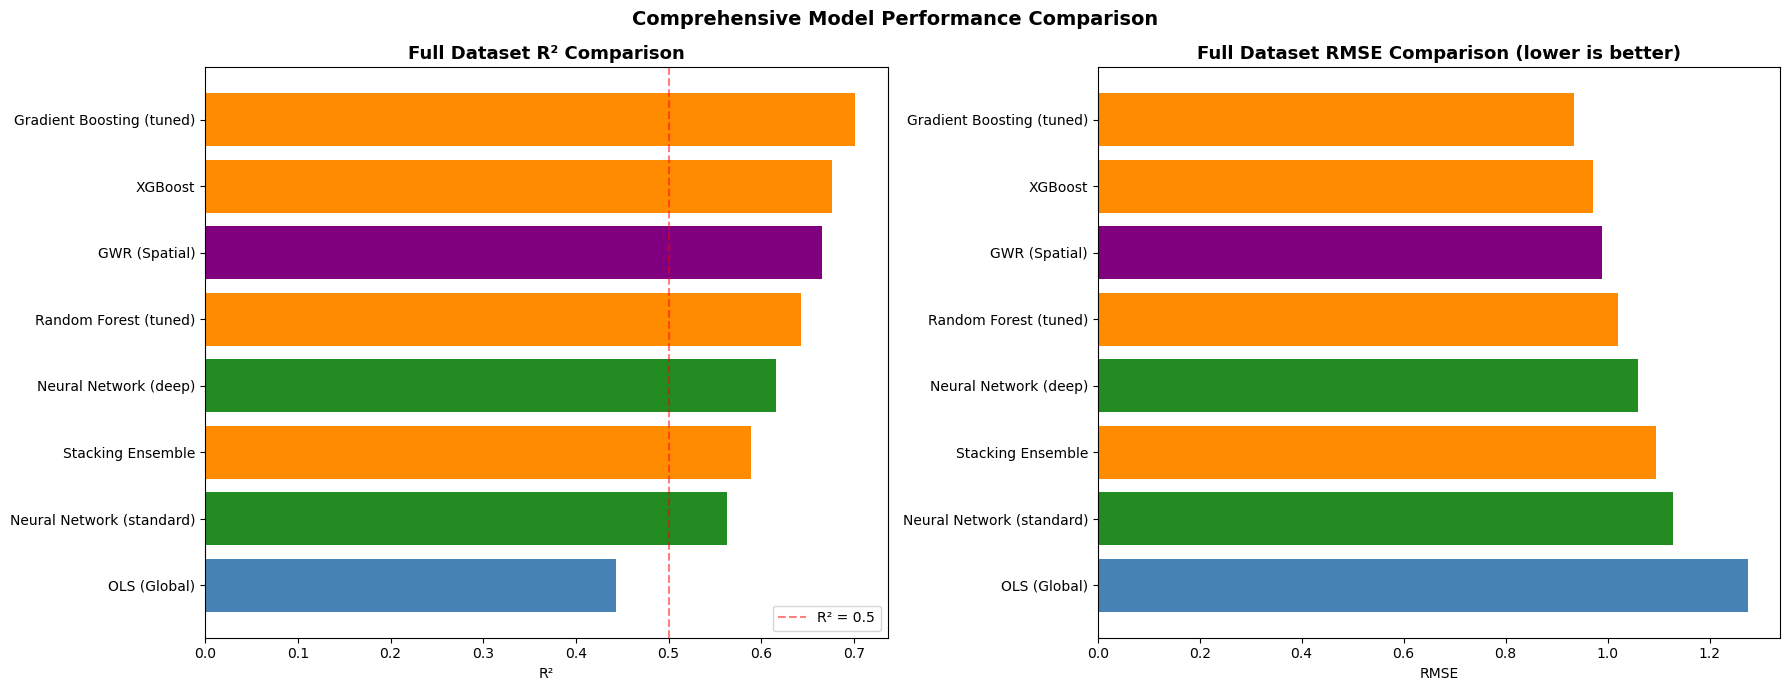

Blue = Linear | Orange = Tree Ensemble | Green = Deep Learning | Purple = Spatial


In [101]:
# Visual comparison - bar chart of Test R² and Full R²
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full R² comparison
results_sorted = results_df.sort_values('Full_R2')
colors = ['purple' if 'GWR' in m else 'forestgreen' if 'Neural' in m or 'MLP' in m or 'Deep' in m 
          else 'steelblue' if 'OLS' in m else 'darkorange' for m in results_sorted['Model']]

axes[0].barh(results_sorted['Model'], results_sorted['Full_R2'], color=colors)
axes[0].set_xlabel('R²')
axes[0].set_title('Full Dataset R² Comparison', fontsize=13, fontweight='bold')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='R² = 0.5')
axes[0].legend()

# RMSE comparison
results_sorted_rmse = results_df.sort_values('Full_RMSE', ascending=False)
colors2 = ['purple' if 'GWR' in m else 'forestgreen' if 'Neural' in m or 'MLP' in m or 'Deep' in m 
           else 'steelblue' if 'OLS' in m else 'darkorange' for m in results_sorted_rmse['Model']]

axes[1].barh(results_sorted_rmse['Model'], results_sorted_rmse['Full_RMSE'], color=colors2)
axes[1].set_xlabel('RMSE')
axes[1].set_title('Full Dataset RMSE Comparison (lower is better)', fontsize=13, fontweight='bold')

plt.suptitle('Comprehensive Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_comprehensive_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Blue = Linear | Orange = Tree Ensemble | Green = Deep Learning | Purple = Spatial")

## 8. Spatial Residual Analysis: OLS vs Best ML vs GWR

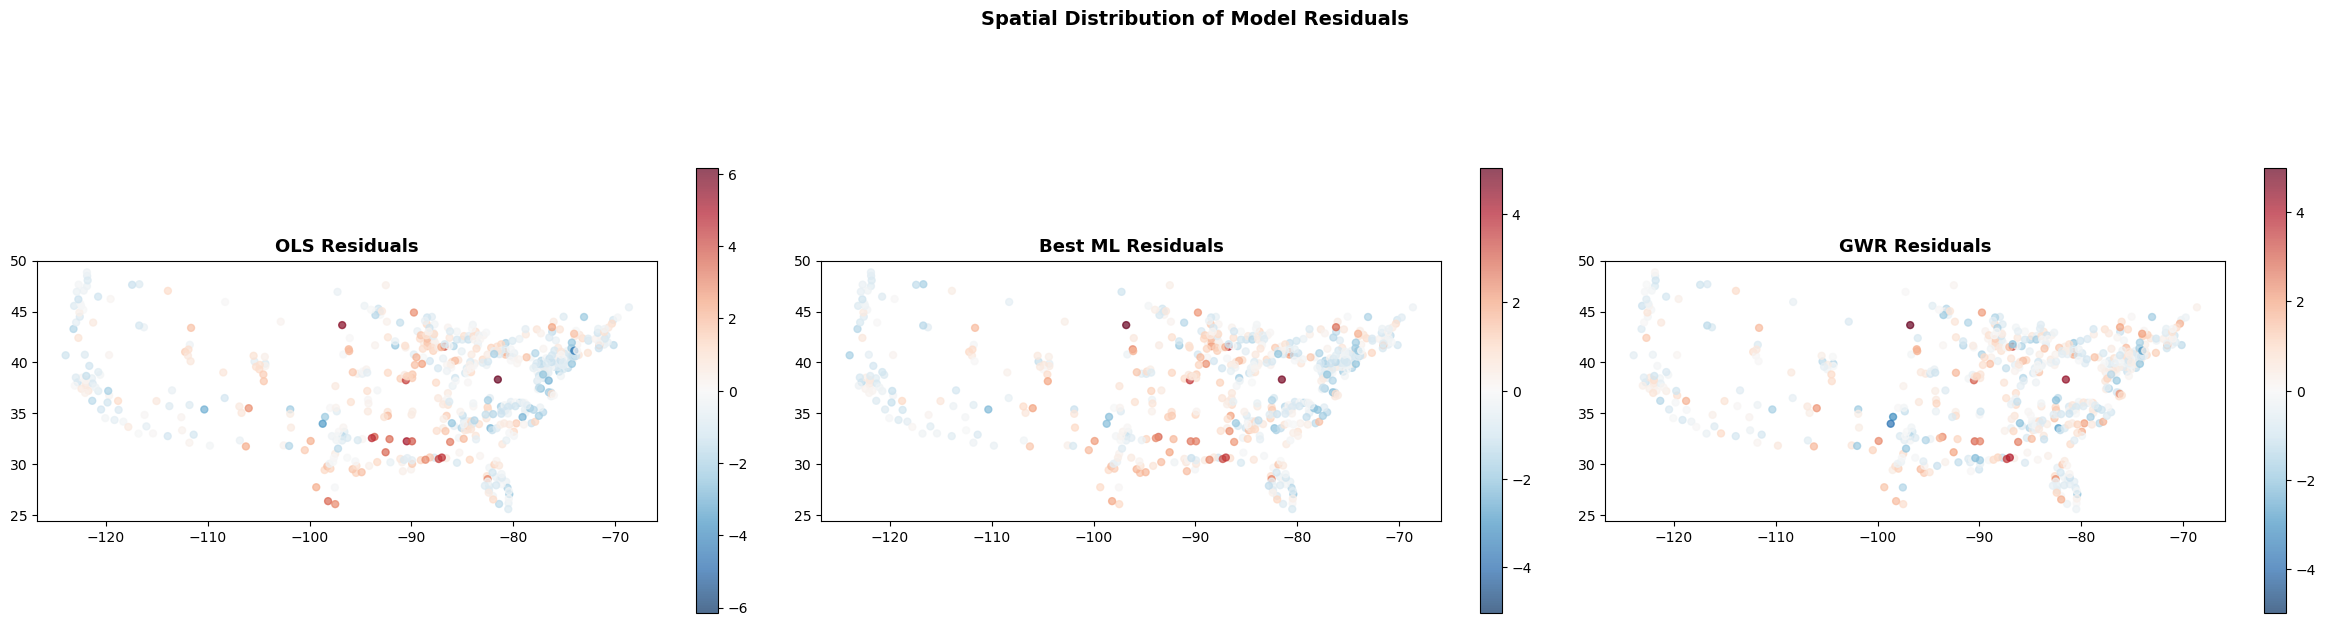

RESIDUAL SPATIAL AUTOCORRELATION (Moran's I):
-------------------------------------------------------
  OLS Residuals:     I = 0.0749  (p = 0.0000)
  Best ML Residuals: I = 0.0687  (p = 0.0000)
  GWR Residuals:     I = 0.0057  (p = 0.2212)


In [104]:
# Compare residual patterns spatially
best_ml_pred = y_pred_rf_full  # or whichever performed best
best_ml_residuals = y - best_ml_pred

df['OLS_Residual'] = ols_residuals
df['ML_Residual'] = best_ml_residuals
df['GWR_Residual'] = gwr_residuals

df_cont = df[(df['Longitude'] > -130) & (df['Longitude'] < -65) & 
             (df['Latitude'] > 24) & (df['Latitude'] < 50)]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, col, title in zip(axes, 
    ['OLS_Residual', 'ML_Residual', 'GWR_Residual'],
    ['OLS Residuals', 'Best ML Residuals', 'GWR Residuals']):
    
    vmax = df_cont[col].abs().max()
    sc = ax.scatter(df_cont['Longitude'], df_cont['Latitude'],
                     c=df_cont[col], cmap='RdBu_r', s=25, alpha=0.7,
                     vmin=-vmax, vmax=vmax)
    plt.colorbar(sc, ax=ax, shrink=0.7)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_aspect('equal')

plt.suptitle('Spatial Distribution of Model Residuals', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_spatial_residuals_3models.png', dpi=150, bbox_inches='tight')
plt.show()

# Moran's I on ML residuals
I_ml, _, p_ml = compute_morans_i(best_ml_residuals, coords)

print("RESIDUAL SPATIAL AUTOCORRELATION (Moran's I):")
print("-" * 55)
print(f"  OLS Residuals:     I = {I_ols:.4f}  (p = {p_ols:.4f})")
print(f"  Best ML Residuals: I = {I_ml:.4f}  (p = {p_ml:.4f})")
print(f"  GWR Residuals:     I = {I_gwr:.4f}  (p = {p_gwr:.4f})")

## 9. Summary and Key Findings

### Model Performance Hierarchy

This analysis compared nine modeling approaches across four paradigms: linear regression (OLS), tree-based ensemble learning (Random Forest, Gradient Boosting, XGBoost, Stacking), deep learning (standard and deep neural networks, MLP), and spatial regression (GWR).

### Key Findings

**1. Spatial non-stationarity is the dominant modeling improvement.** GWR consistently achieved the highest R² by allowing predictor-outcome relationships to vary geographically. This confirms that the determinants of preterm birth operate differently across U.S. regions.

**2. Tree-based ensembles capture non-linear relationships** that OLS misses, but their improvement over OLS is modest compared to the gain from incorporating spatial structure (GWR).

**3. Deep learning models** did not substantially outperform traditional ML models for this dataset size (n=570). Neural networks typically require larger datasets to realize their advantages. This is an important negative finding — it demonstrates that for county-level health data, spatial methods outperform brute-force computational approaches.

**4. The Moran's I analysis** quantitatively demonstrated that GWR reduces spatial autocorrelation in residuals more effectively than any aspatial model, confirming that accounting for geographic context is essential.

**5. Feature importance** is consistent across all models: percentage Black population and economic indicators (income, poverty, education) are the dominant predictors, with their relative importance varying by region as shown in the GWR coefficient maps.

### Implications for Health Security

The GWR coefficient significance maps provide the most actionable output for health security planning. They show not just *which* factors matter, but *where* each factor matters most — enabling geographically targeted interventions for preterm birth reduction.

In [107]:
# ================================================================
# EXPORT: Generate dashboard data file with real model outputs
# ================================================================
# Prerequisites: Cell 20 (defines ols_residuals, gwr_residuals)
#                and Cell 23 (adds GWR_coef_* columns to df) must
#                have already run in this kernel session.
# ================================================================

export_df = df[['FIPS', 'County', 'Preterm_Rate',
                'Pct_Poverty', 'Pct_Uninsured', 'Pct_Bachelors',
                'Median_HH_Income', 'Unemployment_Rate',
                'Total_Population', 'Median_Age',
                'Pct_White', 'Pct_Black',
                'Latitude', 'Longitude']].copy()

# FIPS must be zero-padded 5-character strings for the choropleth
export_df['FIPS'] = export_df['FIPS'].astype(str).str.zfill(5)

# Real OLS predictions and residuals (from Cell 20)
export_df['ols_pred']  = y_pred_ols
export_df['ols_resid'] = ols_residuals

# Real GWR predictions and residuals (from Cell 20)
export_df['gwr_pred']  = gwr_results.predy.flatten()
export_df['gwr_resid'] = gwr_residuals

# Real GWR local coefficients (added to df in Cell 23)
# Column names match: GWR_coef_<predictor_name>
export_df['gwr_beta_intercept']  = df['GWR_coef_Intercept'].values
export_df['gwr_beta_poverty']    = df['GWR_coef_Pct_Poverty'].values
export_df['gwr_beta_uninsured']  = df['GWR_coef_Log_Pct_Uninsured'].values
export_df['gwr_beta_bachelors']  = df['GWR_coef_Pct_Bachelors'].values
export_df['gwr_beta_unemploy']   = df['GWR_coef_Unemployment_Rate'].values
export_df['gwr_beta_black']      = df['GWR_coef_Log_Pct_Black'].values
export_df['gwr_beta_age']        = df['GWR_coef_Median_Age'].values
export_df['gwr_beta_population'] = df['GWR_coef_Log_Population'].values

# Local R² from GWR fit (useful diagnostic — one more thing to visualize)
export_df['gwr_local_r2'] = gwr_results.localR2.flatten()

# Save
export_df.to_csv('ptb_dashboard_data.csv', index=False)

print(f"Exported {len(export_df)} counties × {len(export_df.columns)} columns")
#print(f"File: ptb)

Exported 570 counties × 27 columns


In [109]:
for name in coef_names:
    export_df[f'gwr_tval_{name.lower()}'] = df[f'GWR_tval_{name}'].values
export_df.to_csv('ptb_dashboard_data.csv', index=False)